# 04 `fpos` Model Progression

This notebook is the main positive result of the thesis. It reconstructs the `fpos` path from weak transfer baselines to the final waveform-enhanced, trust-aware, family-balanced winner.

**Questions answered here**
- How much does each modeling wave improve over the simple transfer baseline?
- Which ablation blocks mattered most?
- Were the gains broad across recordings and families, or concentrated in a few easy regimes?


## Model Architecture Rebuild Spec (Code-Accurate)

### Shared Mechanic (Global)

1. **Split protocol used by all models below**: `recording_disjoint_main` from `make_main_split(...)` with `paired_final_holdout_rows=100`, strict recording-disjoint holdout, and no holdout recording leakage into fine-tune or unlabeled pools.

### Per-Model Full Mechanism (Repeated Template; Split Not Repeated)

#### 1) Dummy paired mean (`fpos_dummy`)
- Runner/family: `legacy_transfer` (`DummyRegressor(mean)`).
- Feature path: no engineered stack; scalar target mean from paired labeled fine-tune rows.
- Source transfer path: none (hybrid rows not used).
- Unlabeled/pseudo path: none.
- Trust/manifold/anchor path: none.
- Final learner and fitting: constant mean predictor evaluated on holdout paired rows.
- SSL or representation learning: none.

#### 2) Hybrid+paired basic XGBoost (`fpos_hybrid_plus_paired`)
- Runner/family: `legacy_transfer` candidate `inductive|hybrid_plus_paired|xgboost_w25|unit_raw`.
- Feature path: `unit_raw` transfer features from `prepare_data` in transfer benchmark.
- Source transfer path: supervised hybrid source rows are concatenated with paired labeled rows; paired rows are upweighted (`w=25`).
- Unlabeled/pseudo path: none in this inductive baseline recipe.
- Trust/manifold/anchor path: none.
- Final learner and fitting: XGBoost regressor trained once on train side, evaluated on recording-disjoint holdout.
- SSL or representation learning: none.

#### 3) Best SSL neural (`fpos_ssl`)
- Runner/family: `ssl_neural` (`run_ssl_with_config`).
- Feature path: unit tensor branches (`wf_bin_*`, `acg_*`, scalar) plus curated context columns for contextual arm.
- Source transfer path: supervised source-stage training on hybrid source target (`fpos`) then paired fine-tune.
- Unlabeled/pseudo path: unlabeled paired pool (`ssl_pool`) used for SSL pretraining objective.
- Trust/manifold/anchor path: none (this is not the stack pseudo-label pipeline).
- Final learner and fitting: neural `UnitEncoder` + contextual regressor, then holdout inference.
- SSL or representation learning: yes, masked denoising autoencoder pretraining.

#### 4) Best MMD neural (`fpos_mmd`)
- Runner/family: `mmd_neural` (`run_mmd_with_config`).
- Feature path: unit-input neural features (`wf/acg/scalar`) with paired/context baselines logged separately.
- Source transfer path: supervised source training on hybrid source target with target adaptation.
- Unlabeled/pseudo path: unlabeled paired pool participates in MMD alignment term, not pseudo labels.
- Trust/manifold/anchor path: none.
- Final learner and fitting: `task_loss(source) + lambda*MMD(latent_source, latent_unlabeled)`; lambda selected by grouped CV; holdout retrain for final rows.
- SSL or representation learning: no SSL pretrain; domain alignment is MMD only.

#### 5) Paired-only context (`fpos_paired_context` -> `contextual_paired_only_lightgbm`)
- Runner/family: `context_stack` from compact stacking runner.
- Feature path: filtered context columns only (no `source_pred`, no anchor/support columns).
- Source transfer path: none in this variant.
- Unlabeled/pseudo path: disabled (`no_pseudo=True` branch in variant spec).
- Trust/manifold/anchor path: not applied in training features.
- Final learner and fitting: grouped OOF + final LightGBM on paired labeled rows only.
- SSL or representation learning: none.

#### 6) Context-first source stack (`fpos_context_stack` -> `embed_nommd_fullctx_lightgbm`)
- Runner/family: `context_stack` full-stack variant.
- Feature path: filtered context columns + stack extras (`source_pred`, `anchor_fp_score`, `matched_support_conf`, `anchor_support_margin`).
- Source transfer path: three teacher models are fit with grouped OOF; weighted teacher predictions produce `source_pred` priors.
- Unlabeled/pseudo path: pseudo candidates from PCA(10)+KNN(16)+KMeans(4), support/agreement quantiles, cluster/recording quotas.
- Trust/manifold/anchor path: pseudo weights are trust-adjusted with `cluster_trust_power=1.35`, `study_trust_weight=0.30`, `min_trust=0.25`; anchor score model is HistGradientBoostingClassifier (`lr=0.06`, `max_depth=4`, `max_iter=250`).
- Final learner and fitting: grouped OOF excludes pseudo rows sharing validation recordings; final LightGBM on labeled + selected pseudo rows with family weights.
- SSL or representation learning: none.

#### 7) Pre-waveform unlabeled structure (`fpos_pre_waveform_unlabeled` -> `source_reweighted_anchor_stack_cluster_trust_pseudo_xgboost_default`)
- Runner/family: `anchor_stack` backend sweep winner.
- Feature path: anchor stack columns (`context + source_pred + anchor/support` extras).
- Source transfer path: source-reweighted teacher prior injected as `source_pred`.
- Unlabeled/pseudo path: same manifold pseudo-label pipeline (candidate gates + quotas + trust-adjusted pseudo weights).
- Trust/manifold/anchor path: fully active (cluster and study trust + anchor score + support margin).
- Final learner and fitting: XGBoost backend (`xgboost_default`) with weighted labeled + pseudo rows.
- SSL or representation learning: none.

#### 8) Family-balanced robustness (`fpos_family_balanced` -> `family_balanced_strong_xgboost`)
- Runner/family: `robustness_stack` variant sweep.
- Feature path: same anchor stack frame as above.
- Source transfer path: same source teacher prior (`source_pred`).
- Unlabeled/pseudo path: same trust-selected pseudo pool.
- Trust/manifold/anchor path: same manifold support, trust reweighting, and anchor features.
- Final learner and fitting: XGBoost with explicit family balancing (`family_alpha=1.0`) to flatten `study_set` imbalance.
- SSL or representation learning: none.

#### 9) Waveform winner (`fpos_waveform_winner` -> `wf_embed_anchor_stack_xgboost`)
- Runner/family: `waveform_stack` signal-embedding variant.
- Feature path: full anchor stack frame plus learned waveform latent columns `wf_embed_*` (and in family sweep also `acg_embed_*` candidates).
- Source transfer path: same teacher prior pipeline provides `source_pred`.
- Unlabeled/pseudo path: same trust-selected pseudo rows and sample-weight path.
- Trust/manifold/anchor path: same manifold support, trust adjustment, and anchor margin columns.
- Final learner and fitting: XGBoost on labeled + trust-selected pseudo rows after embedding augmentation.
- SSL or representation learning: waveform convolutional autoencoder is used for embedding; no SSL domain-adaptation pretraining.


In [11]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve().parent
SRC = ROOT / "src"
if not SRC.exists():
    raise FileNotFoundError(f"Expected thesis src at {SRC}; run notebooks from thesis/notebooks")
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("04_fpos_model_progression")
benchmark = build_benchmark_progress_table("fpos")
ablation_winners = build_ablation_winner_table("fpos")
wave_ids = ["fpos_paired_context", "fpos_context_stack", "fpos_pre_waveform_unlabeled", "fpos_family_balanced", "fpos_waveform_winner"]
waves = build_main_wave_summary("fpos", wave_ids)
winner_diag = build_prediction_diagnostics("fpos_waveform_winner", "fpos")
limitations = get_limitations_bundle()


## 0. Recipe system: running the experiments

The thesis uses a recipe-based experiment system. Each `RecipeSpec` encodes a complete modeling hypothesis: target, feature view, model family, ablation group, and result key. `load_or_run_experiment` checks for cached artifacts first and runs the recipe live only when needed.

The full `fpos` research path below has seven stages. Stages 3 and 4 (SSL, MMD) are the necessary detour that ruled out neural domain adaptation before the tabular stacking breakthrough.

In [12]:
PROTOCOL = "recording_disjoint_main"

# Load or run every key milestone — cached on disk, runs live if missing
result_dummy       = load_or_run_experiment("fpos_dummy",                "fpos", PROTOCOL)
result_basic       = load_or_run_experiment("fpos_hybrid_plus_paired",   "fpos", PROTOCOL)
result_ssl         = load_or_run_experiment("fpos_ssl",                  "fpos", PROTOCOL)
result_mmd         = load_or_run_experiment("fpos_mmd",                  "fpos", PROTOCOL)
result_context     = load_or_run_experiment("fpos_context_stack",        "fpos", PROTOCOL)
result_unlabeled   = load_or_run_experiment("fpos_pre_waveform_unlabeled","fpos", PROTOCOL)
result_winner      = load_or_run_experiment("fpos_waveform_winner",      "fpos", PROTOCOL)

def _m(result):
    row = result.metrics.iloc[0] if not result.metrics.empty else {}
    return {"r2": float(row.get("r2", float("nan"))), "mae": float(row.get("mae", float("nan")))}

milestones = pd.DataFrame([
    {"stage": "1  sanity floor",         "model": result_dummy.recipe.label,     **_m(result_dummy)},
    {"stage": "2  basic transfer",        "model": result_basic.recipe.label,     **_m(result_basic)},
    {"stage": "3  neural SSL",            "model": result_ssl.recipe.label,       **_m(result_ssl)},
    {"stage": "4  neural MMD",            "model": result_mmd.recipe.label,       **_m(result_mmd)},
    {"stage": "5  context stacking",      "model": result_context.recipe.label,   **_m(result_context)},
    {"stage": "6  + unlabeled paired",    "model": result_unlabeled.recipe.label, **_m(result_unlabeled)},
    {"stage": "7  + waveform embedding",  "model": result_winner.recipe.label,    **_m(result_winner)},
])
display(milestones)
save_table(milestones, table_dir, "fpos_milestone_trajectory")

,stage,model,r2,mae
0,1 sanity floor,Dummy paired mean,-0.000221,0.191016
1,2 basic transfer,Hybrid+paired basic XGBoost,0.270975,0.148397
2,3 neural SSL,Best SSL neural,-1.057136,0.276944
3,4 neural MMD,Best MMD neural,0.304869,0.150319
4,5 context stacking,Context-first source stack,0.521520,0.118961
5,6 + unlabeled paired,Pre-waveform unlabeled structure,0.501473,0.117866
6,7 + waveform embedding,Waveform winner,0.533189,0.116062


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/04_fpos_model_progression/fpos_milestone_trajectory.csv')

## 1. Benchmark ladder

The right baseline for the thesis is not the dummy model; it is the **basic hybrid+paired XGBoost transfer baseline**. Everything after that should be interpreted as an incremental answer to a specific scientific problem.


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer,delta_mae_vs_basic_transfer,notes
0,Dummy paired mean,0.191016,0.246455,-0.000221,-0.003661,0.000000,-0.271196,0.042619,Sanity floor
0,Paired-only raw,0.123640,0.174319,0.499605,-0.035659,0.963795,0.228629,-0.024757,Small paired baseline
0,Hybrid-only XGBoost,0.251464,0.341916,-0.925127,0.178861,0.391856,-1.196102,0.103067,Pure source failure baseline
0,Calibrated hybrid XGBoost,0.157333,0.222267,0.186473,-0.018288,1.075657,-0.084502,0.008936,Simple calibrated transfer
0,Hybrid+paired basic XGBoost,0.148397,0.210407,0.270975,0.079370,0.665509,0.000000,0.000000,Basic transfer baseline
0,Hybrid stack residual,0.147101,0.193101,0.385967,0.031573,0.768012,0.114992,-0.001296,First nonlinear stack
0,Paired-only context,0.132842,0.179832,0.467458,-0.033665,1.026478,0.196482,-0.015555,Context-only target baseline
0,Context-first source stack,0.118961,0.170459,0.521520,-0.037415,1.211901,0.250544,-0.029437,Best pre-unlabeled context-first stack
0,Best SSL neural,0.276944,0.353444,-1.057136,0.194436,0.365486,-1.328111,0.128546,Best SSL comparison
0,Best MMD neural,0.150319,0.205458,0.304869,0.027606,0.712287,0.033894,0.001922,Best MMD comparison


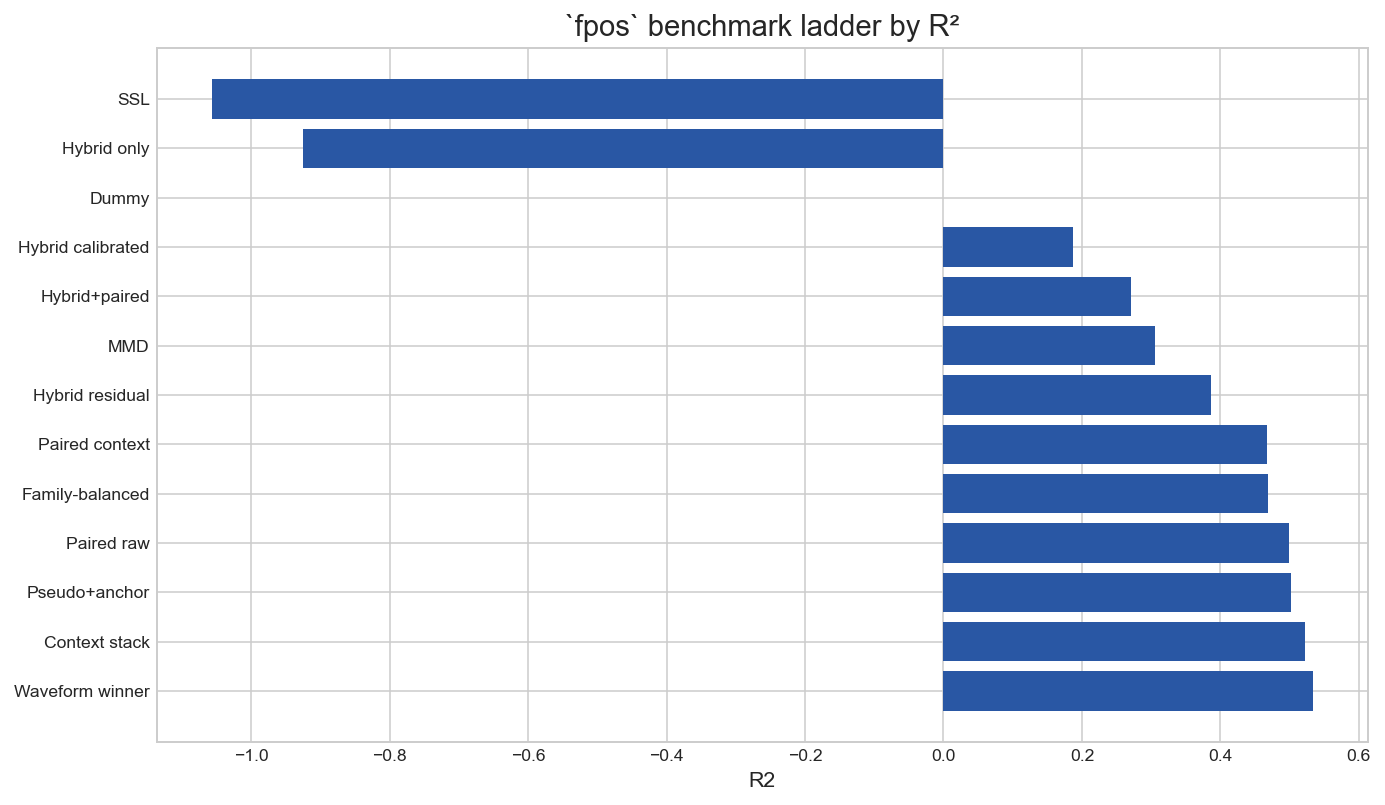

In [13]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer", "delta_mae_vs_basic_transfer", "notes"]])
save_table(benchmark, table_dir, "fpos_benchmark_ladder")
fig, _ = plot_benchmark_metric(benchmark, metric="r2", title="`fpos` benchmark ladder by R²")
save_figure(fig, fig_dir, "fpos_benchmark_r2")
display(fig)
plt.close(fig)


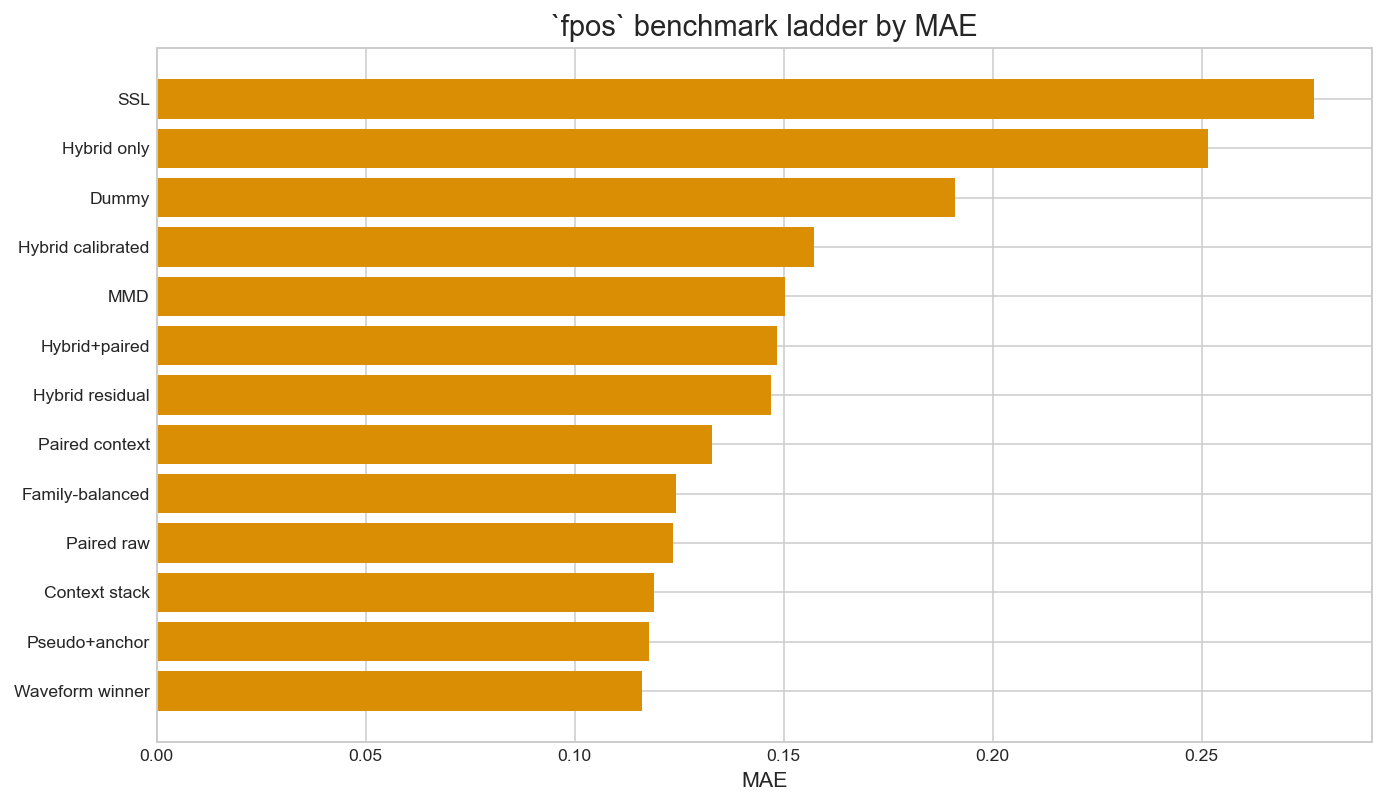

In [14]:
fig, _ = plot_benchmark_metric(benchmark, metric="mae", title="`fpos` benchmark ladder by MAE")
save_figure(fig, fig_dir, "fpos_benchmark_mae")
display(fig)
plt.close(fig)


In [15]:
winner_row = benchmark.sort_values("r2", ascending=False).iloc[0]
simple_row = benchmark.loc[benchmark["recipe_id"] == "fpos_hybrid_plus_paired"].iloc[0]
display(Markdown(
    f"""
## Main progression result

- The simple hybrid+paired baseline reaches **R² {simple_row['r2']:.4f}**.
- The final waveform winner reaches **R² {winner_row['r2']:.4f}**.
- That is a gain of **{winner_row['r2'] - simple_row['r2']:+.4f} R²** over the basic transfer recipe.
- The thesis should therefore present `fpos` as a sequence of answers: context, unlabeled target structure, robustness weighting, and waveform representation.
"""
))



## Main progression result

- The simple hybrid+paired baseline reaches **R² 0.2710**.
- The final waveform winner reaches **R² 0.5332**.
- That is a gain of **+0.2622 R²** over the basic transfer recipe.
- The thesis should therefore present `fpos` as a sequence of answers: context, unlabeled target structure, robustness weighting, and waveform representation.


### A necessary detour: neural domain adaptation

Before the context-first tabular stacking path became clear, two neural domain adaptation strategies were attempted. Both had strong priors in the transfer learning literature. Both were eventually ruled out.

**SSL autoencoder pretraining**  
Pretrained a unit-level encoder on ~4963 unlabeled paired units, trained on hybrid labels, then fine-tuned on the 107 paired labeled rows. The neural model learned a useful latent structure on unlabeled data but the fine-tuning stage collapsed — the paired labeled budget was too small to steer contextual neural layers reliably. The network settled into narrow prediction ranges close to the paired mean.

**MMD domain alignment**  
Added a domain alignment term to the neural training objective: `task_loss(hybrid) + λ·MMD(hybrid_latent, paired_unlabeled_latent)`. MMD improved neural stability compared to plain SSL. However, the tabular context stack — which uses recording-level inter-unit statistics as features — still dominated.

**The lesson**: The strongest domain-shift-aware signal in this problem lives in hand-crafted context features (study-set indicators, recording-level statistics, inter-unit amplitude ratios), not in learned neural embeddings. The unlabeled paired pool is better used structurally — as an anchor pool for pseudo-labeling and manifold scoring — than as a pretraining corpus.

In [16]:
# Direct numeric comparison: neural attempts vs tabular context baseline
neural_compare = pd.DataFrame([
    {
        "model":    result_ssl.recipe.label,
        "approach": "SSL autoencoder (neural)",
        **_m(result_ssl),
        "notes":    result_ssl.recipe.notes,
    },
    {
        "model":    result_mmd.recipe.label,
        "approach": "MMD alignment (neural)",
        **_m(result_mmd),
        "notes":    result_mmd.recipe.notes,
    },
    {
        "model":    result_context.recipe.label,
        "approach": "Context-first tabular stack",
        **_m(result_context),
        "notes":    result_context.recipe.notes,
    },
])
display(neural_compare[["model", "approach", "r2", "mae", "notes"]])
save_table(neural_compare, table_dir, "fpos_neural_vs_tabular_comparison")

ssl_r2 = _m(result_ssl)["r2"]
mmd_r2 = _m(result_mmd)["r2"]
ctx_r2 = _m(result_context)["r2"]
display(Markdown(
    f"SSL R² **{ssl_r2:.4f}** · MMD R² **{mmd_r2:.4f}** · Context stack R² **{ctx_r2:.4f}**"
    f"  → tabular context advantage: **{ctx_r2 - max(ssl_r2, mmd_r2):+.4f} R²**"
))

,model,approach,r2,mae,notes
0,Best SSL neural,SSL autoencoder (neural),-1.057136,0.276944,Best SSL comparison
1,Best MMD neural,MMD alignment (neural),0.304869,0.150319,Best MMD comparison
2,Context-first source stack,Context-first tabular stack,0.521520,0.118961,Best pre-unlabeled context-first stack


SSL R² **-1.0571** · MMD R² **0.3049** · Context stack R² **0.5215**  → tabular context advantage: **+0.2167 R²**

## 2. Which ablation blocks mattered?

Each ablation group corresponds to one scientific question. The goal is not to show every run equally, but to make the causal story of the winner understandable.


In [17]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fpos_ablation_winners")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_supervision,Paired-only raw,fpos_paired_raw,0.499605,0.123640,Small paired baseline
1,context,Context-first source stack,fpos_context_stack,0.521520,0.118961,Best pre-unlabeled context-first stack
2,unlabeled_paired_structure,Context-first source stack,fpos_context_stack,0.521520,0.118961,Best pre-unlabeled context-first stack
3,waveform_representation,Waveform winner,fpos_waveform_winner,0.533189,0.116062,Final fpos winner
4,robustness,Waveform winner,fpos_waveform_winner,0.533189,0.116062,Final fpos winner


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/04_fpos_model_progression/fpos_ablation_winners.csv')

In [18]:
for group_name in ["source_supervision", "context", "unlabeled_paired_structure", "waveform_representation", "robustness"]:
    bundle = build_ablation_bundle("fpos", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fpos_ablation_{group_name}")


### Source Supervision

,label,mae,r2,notes
0,Dummy paired mean,0.191016,-0.000221,Sanity floor
0,Paired-only raw,0.123640,0.499605,Small paired baseline
0,Hybrid-only XGBoost,0.251464,-0.925127,Pure source failure baseline
0,Calibrated hybrid XGBoost,0.157333,0.186473,Simple calibrated transfer
0,Hybrid+paired basic XGBoost,0.148397,0.270975,Basic transfer baseline
0,Hybrid stack residual,0.147101,0.385967,First nonlinear stack


### Context

,label,mae,r2,notes
0,Paired-only raw,0.123640,0.499605,Small paired baseline
0,Paired-only context,0.132842,0.467458,Context-only target baseline
0,Context-first source stack,0.118961,0.521520,Best pre-unlabeled context-first stack


### Unlabeled Paired Structure

,label,mae,r2,notes
0,Context-first source stack,0.118961,0.521520,Best pre-unlabeled context-first stack
0,Pre-waveform unlabeled structure,0.117866,0.501473,Strongest positive result before waveform embe...
0,Family-balanced robustness,0.124264,0.468913,Robustness tradeoff variant


### Waveform Representation

,label,mae,r2,notes
0,Pre-waveform unlabeled structure,0.117866,0.501473,Strongest positive result before waveform embe...
0,Family-balanced robustness,0.124264,0.468913,Robustness tradeoff variant
0,Waveform winner,0.116062,0.533189,Final fpos winner


### Robustness

,label,mae,r2,notes
0,Pre-waveform unlabeled structure,0.117866,0.501473,Strongest positive result before waveform embe...
0,Family-balanced robustness,0.124264,0.468913,Robustness tradeoff variant
0,Waveform winner,0.116062,0.533189,Final fpos winner


## 3. Family and recording behavior of the main waves

The thesis should not claim improvement unless it can show that gains are broad. These summaries make it clear whether a new wave improved many recordings or only a handful.


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN,21,0.088048,0.121570,-0.863455,0.021138
1,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1,9,0.159556,0.208522,0.485703,-0.045567
2,fpos_paired_context,Paired-only context,PAIRED_ENGLISH,44,0.180991,0.225780,0.405088,-0.039343
3,fpos_paired_context,Paired-only context,PAIRED_KAMPFF,6,0.125307,0.144412,0.583394,-0.125307
4,fpos_paired_context,Paired-only context,PAIRED_MEA64C_YGER,20,0.064190,0.090593,0.385658,-0.045870
5,fpos_context_stack,Context-first source stack,PAIRED_BOYDEN,21,0.039797,0.052860,0.647694,0.000703
6,fpos_context_stack,Context-first source stack,PAIRED_CRCNS_HC1,9,0.141149,0.210923,0.473791,-0.083238
7,fpos_context_stack,Context-first source stack,PAIRED_ENGLISH,44,0.185454,0.226628,0.400612,-0.040691
8,fpos_context_stack,Context-first source stack,PAIRED_KAMPFF,6,0.107709,0.130946,0.657469,-0.102544
9,fpos_context_stack,Context-first source stack,PAIRED_MEA64C_YGER,20,0.049187,0.064745,0.686219,-0.030075


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10,0.121279,0.160870,-3.176908,0.101827
1,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11,0.057838,0.068472,-0.050129,-0.052215
2,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1,0.321540,0.321540,NaN,-0.321540
3,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8,0.139308,0.189718,-0.032248,-0.011071
4,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3,0.307830,0.315963,-5.015567,-0.307830
5,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7,0.142988,0.153025,-1.419613,0.142988
6,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3,0.027625,0.032501,0.835701,0.025347
7,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6,0.266153,0.296268,0.032908,-0.091546
8,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6,0.125938,0.186152,0.643359,-0.012124
9,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3,0.155864,0.182182,-0.166735,-0.155864


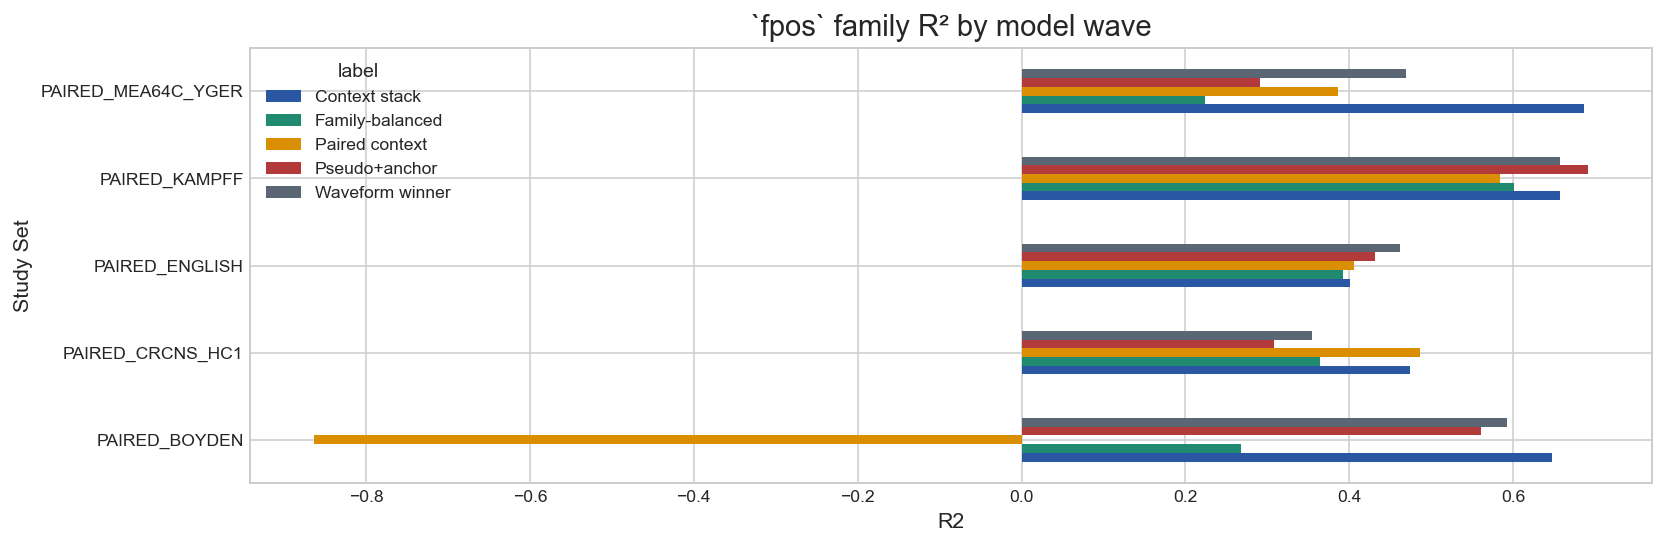

In [19]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fpos_family_wave_summary")
save_table(waves["recording"], table_dir, "fpos_recording_wave_summary")
fig, _, family_pivot = plot_group_metric(waves["family"], group_col="study_set", metric="r2", title="`fpos` family R² by model wave")
save_figure(fig, fig_dir, "fpos_family_r2_by_wave")
save_table(family_pivot, table_dir, "fpos_family_r2_pivot")
display(fig)
plt.close(fig)


,label,recording_key,r2
0,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.746651
1,Waveform winner,PAIRED_KAMPFF::paired_kampff::c14,0.657032
2,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.495859
3,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,0.491276
4,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,0.253259
5,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.253114
6,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.107102
7,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.072563
8,Waveform winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.070563
9,Waveform winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-0.389054


,label,recording_key,r2
0,Waveform winner,PAIRED_ENGLISH::paired_english::m139_200114_19...,-3.149280
1,Waveform winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-1.120369
2,Waveform winner,PAIRED_ENGLISH::paired_english::m139_200114_22...,-1.075727
3,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,-0.587313
4,Waveform winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-0.389054
5,Waveform winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.070563
6,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.072563
7,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.107102
8,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.253114
9,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,0.253259


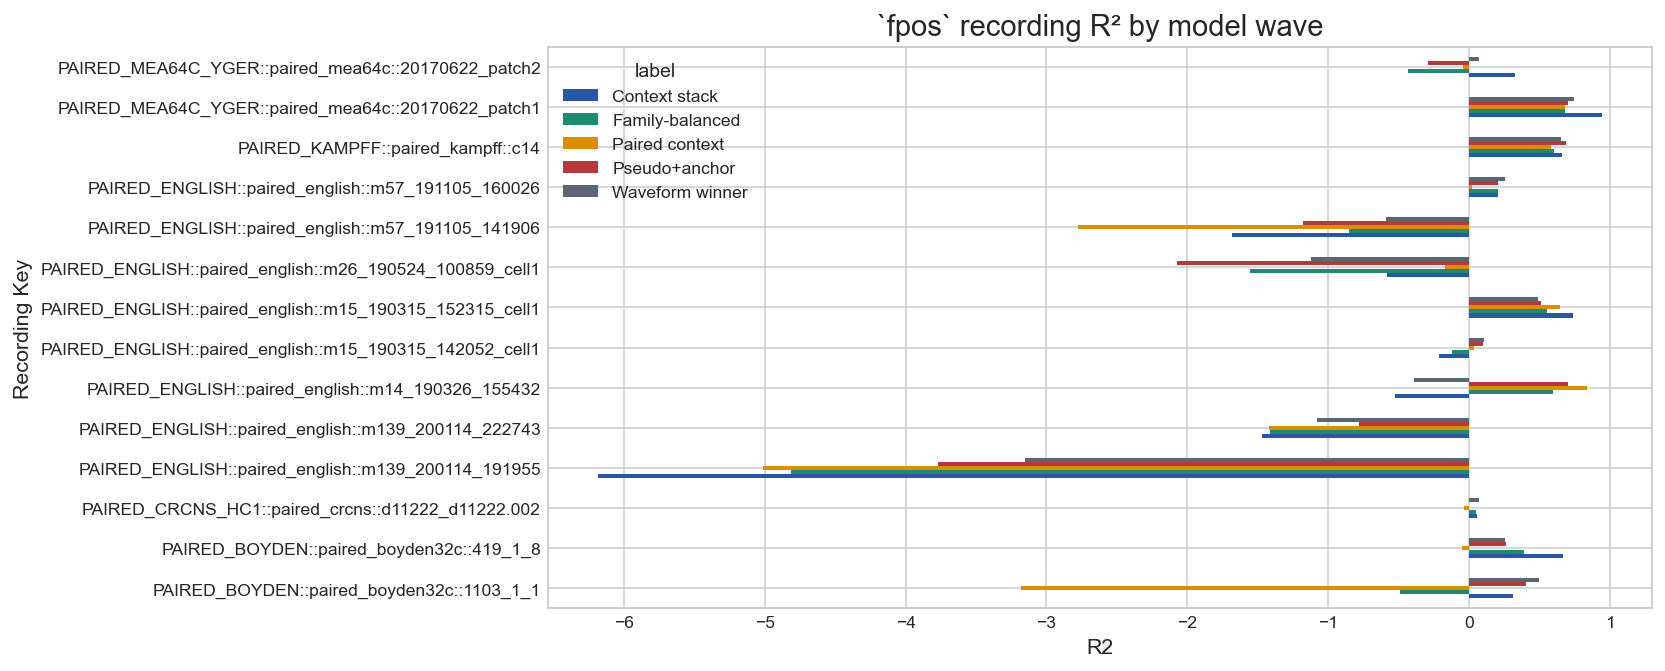

In [20]:
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(recording_mean[recording_mean["label"] == "Waveform winner"], group_col="recording_key", metric="r2", top_n=12)
display(top_rec)
display(bottom_rec)
save_table(top_rec, table_dir, "fpos_top_recordings")
save_table(bottom_rec, table_dir, "fpos_worst_recordings")
fig, _, rec_pivot = plot_group_metric(waves["recording"], group_col="recording_key", metric="r2", title="`fpos` recording R² by model wave")
save_figure(fig, fig_dir, "fpos_top_recording_r2_by_wave")
save_table(rec_pivot, table_dir, "fpos_recording_r2_pivot")
display(fig)
plt.close(fig)


## 4. Diagnostics for the final winner

The final model is not only a score. We also want a structural read: does it track the target at all, and what robustness cost does it pay under family-unseen transfer?


,protocol,target,variant_id,family,backend,row_uid,recording_key,study_set,true,pred,abs_error,recipe_id,label,residual
0,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Iro...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.113636,0.152797,0.039161,fpos_waveform_winner,Waveform winner,0.039161
1,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::JRC...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261381,0.284694,0.023313,fpos_waveform_winner,Waveform winner,0.023313
2,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.112410,0.169673,0.057263,fpos_waveform_winner,Waveform winner,0.057263
3,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.170663,0.196328,0.025665,fpos_waveform_winner,Waveform winner,0.025665
4,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.333333,0.207217,0.126116,fpos_waveform_winner,Waveform winner,-0.126116
5,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.158784,0.099575,0.059209,fpos_waveform_winner,Waveform winner,-0.059209
6,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Klu...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.156687,0.203055,0.046368,fpos_waveform_winner,Waveform winner,0.046368
7,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Mou...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.305322,0.312948,0.007626,fpos_waveform_winner,Waveform winner,0.007626
8,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Spy...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.122581,0.176133,0.053552,fpos_waveform_winner,Waveform winner,0.053552
9,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Tri...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261327,0.288410,0.027083,fpos_waveform_winner,Waveform winner,0.027083


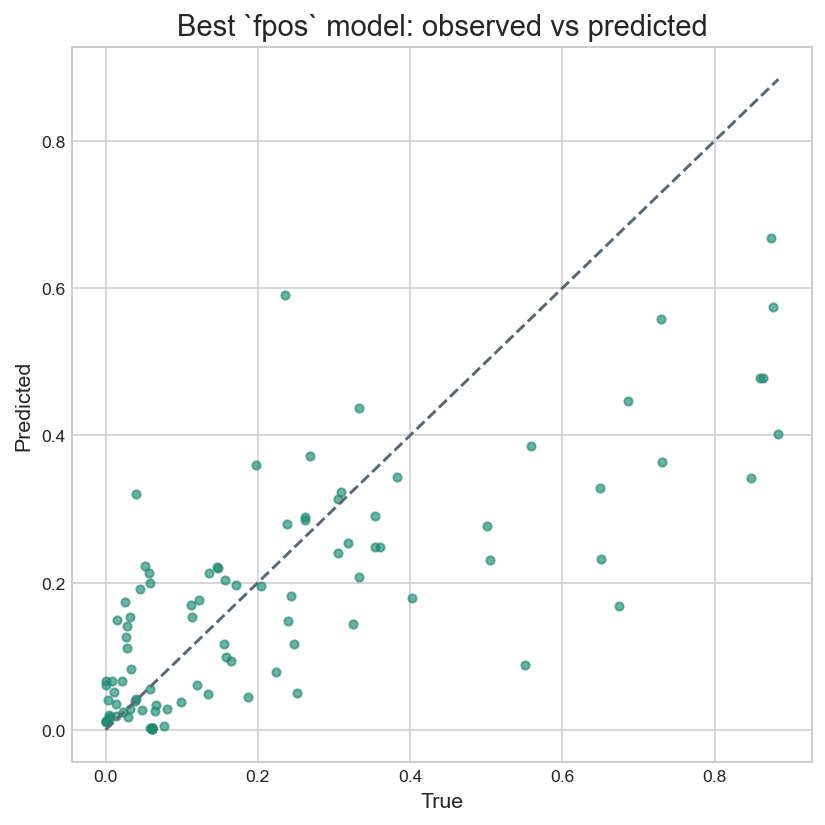

In [21]:
winner_predictions = winner_diag["predictions"]
display(winner_predictions.head(20))
fig, _ = plot_prediction_scatter(winner_predictions, title="Best `fpos` model: observed vs predicted")
save_figure(fig, fig_dir, "fpos_winner_prediction_scatter")
display(fig)
plt.close(fig)


,variant_id,macro_mae,macro_r2,weighted_mae,weighted_r2,worst_family_r2,best_family_r2
0,reference_anchor_stack_xgboost,0.125455,0.452724,0.131071,0.423981,0.293988,0.546858
1,wf_embed_anchor_stack_xgboost,0.122189,0.438568,0.126716,0.411617,0.148179,0.695184


,model,protocol,r2,mae,delta_r2_vs_recording,delta_mae_vs_recording
0,Waveform winner,recording_disjoint_main,0.533189,0.116062,0.000000,0.000000
1,Waveform winner,family_disjoint_lofo,0.438568,0.122189,-0.094622,0.006128


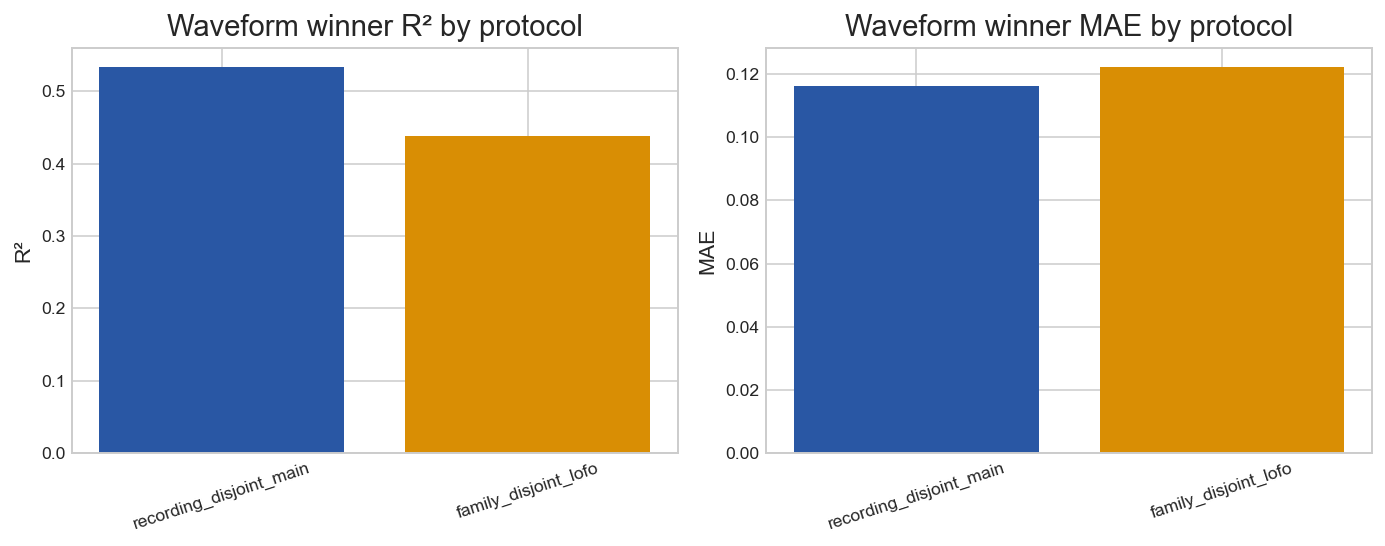

In [22]:
lofo_companion = limitations.lofo_aggregate[limitations.lofo_aggregate["variant_id"].isin(["reference_anchor_stack_xgboost", "family_balanced_strong_xgboost", "wf_embed_anchor_stack_xgboost"])].copy()
display(lofo_companion)
save_table(lofo_companion, table_dir, "fpos_family_held_out_companion")

winner_variant = "wf_embed_anchor_stack_xgboost"
winner_recording_r2 = float(result_winner.metrics.iloc[0]["r2"])
winner_recording_mae = float(result_winner.metrics.iloc[0]["mae"])
winner_lofo = limitations.lofo_aggregate.loc[limitations.lofo_aggregate["variant_id"].astype(str) == winner_variant].copy()
if winner_lofo.empty:
    raise RuntimeError(f"Missing family-disjoint aggregate row for {winner_variant}")
winner_lofo_row = winner_lofo.iloc[0]

winner_protocol_compare = pd.DataFrame([
    {
        "model": "Waveform winner",
        "protocol": "recording_disjoint_main",
        "r2": winner_recording_r2,
        "mae": winner_recording_mae,
    },
    {
        "model": "Waveform winner",
        "protocol": "family_disjoint_lofo",
        "r2": float(winner_lofo_row["macro_r2"]),
        "mae": float(winner_lofo_row["macro_mae"]),
    },
])
winner_protocol_compare["delta_r2_vs_recording"] = winner_protocol_compare["r2"] - winner_recording_r2
winner_protocol_compare["delta_mae_vs_recording"] = winner_protocol_compare["mae"] - winner_recording_mae
display(winner_protocol_compare)
save_table(winner_protocol_compare, table_dir, "fpos_winner_protocol_comparison")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(winner_protocol_compare["protocol"], winner_protocol_compare["r2"], color=["#2957a4", "#d98e04"])
axes[0].set_title("Waveform winner R² by protocol")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(winner_protocol_compare["protocol"], winner_protocol_compare["mae"], color=["#2957a4", "#d98e04"])
axes[1].set_title("Waveform winner MAE by protocol")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=18)
fig.tight_layout()
save_figure(fig, fig_dir, "fpos_winner_protocol_comparison")
display(fig)
plt.close(fig)


In [23]:
display(Markdown(
    f"""
## Key takeaways

- `fpos` improves in a staged way: **context -> unlabeled paired structure -> robustness weighting -> waveform representation**.
- The final winner has mean absolute error **{winner_diag['mae']:.4f}** on the saved holdout predictions and a true/predicted correlation of **{winner_diag['correlation']:.3f}**.
- The protocol comparison table/plot makes the tradeoff explicit: recording-disjoint headline performance is higher than family-disjoint performance for the same winner.
- The family-held-out companion table remains essential: the waveform winner is the headline model for the main benchmark, but not the safest unseen-family model.
"""
))



## Key takeaways

- `fpos` improves in a staged way: **context -> unlabeled paired structure -> robustness weighting -> waveform representation**.
- The final winner has mean absolute error **0.1161** on the saved holdout predictions and a true/predicted correlation of **0.771**.
- The protocol comparison table/plot makes the tradeoff explicit: recording-disjoint headline performance is higher than family-disjoint performance for the same winner.
- The family-held-out companion table remains essential: the waveform winner is the headline model for the main benchmark, but not the safest unseen-family model.
